In [1]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import sunpy.visualization.colormaps as sunpycm
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path
from sunpy.visualization.colormaps import color_tables
from omegaconf import OmegaConf

from sdofmv2.core import SDOMLDataModule, MAE, inverse_log_norm
from sdofmv2.tasks.missing_data import MissingDataModel

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
def get_file_name(file_path: str):
    file = Path(file_path)
    return file.name

In [4]:
cfg = OmegaConf.load("../../../../configs/downstream/missing_channel_sdofmv2_AIA.yaml")

cache_dir = "../../../../assets/cache/missing_channel/"
train_index = get_file_name(cfg.data.train_index)
val_index = get_file_name(cfg.data.val_index)
test_index = get_file_name(cfg.data.test_index)

data_module = SDOMLDataModule(
    hmi_path=(
        os.path.join(
            cfg.data.sdoml.base_directory,
            cfg.data.sdoml.sub_directory.hmi,
        )
        if cfg.data.sdoml.sub_directory.hmi
        else None
    ),
    aia_path=(
        os.path.join(
            cfg.data.sdoml.base_directory,
            cfg.data.sdoml.sub_directory.aia,
        )
        if cfg.data.sdoml.sub_directory.aia
        else None
    ),
    eve_path=None,
    components=cfg.data.sdoml.components,
    wavelengths=cfg.data.sdoml.wavelengths,
    ions=cfg.data.sdoml.ions,
    batch_size=cfg.model.misc.batch_size,
    num_workers=cfg.data.num_workers,
    pin_memory=cfg.data.pin_memory,
    persistent_workers=cfg.data.persistent_workers,
    multiprocessing_context=cfg.data.multiprocessing_context,
    normalization=cfg.data.sdoml.normalization,
    normalization_stat_path=cache_dir,
    train_index=cache_dir + train_index,
    val_index=cache_dir + val_index,
    test_index=cache_dir + test_index,
    hmi_mask_path=cfg.data.hmi_mask,
    apply_mask=cfg.data.sdoml.apply_mask,
    num_frames=cfg.data.num_frames,
    drop_frame_dim=cfg.data.drop_frame_dim,
    precision=cfg.experiment.precision,
)
data_module.setup()
channels = data_module.wavelengths

2026-06-16 01:10:53.775 | INFO     | sdofmv2.core.datamodule:setup:643 - Train dataloader is ready!
2026-06-16 01:10:53.775 | INFO     | sdofmv2.core.datamodule:setup:644 - Dataset size: 28169
2026-06-16 01:10:53.778 | INFO     | sdofmv2.core.datamodule:setup:662 - Validation dataloader is ready!
2026-06-16 01:10:53.779 | INFO     | sdofmv2.core.datamodule:setup:663 - Dataset size: 2867
2026-06-16 01:10:53.781 | INFO     | sdofmv2.core.datamodule:setup:681 - test dataloader is ready!
2026-06-16 01:10:53.782 | INFO     | sdofmv2.core.datamodule:setup:682 - Dataset size: 2966


In [7]:
backbone = MAE.load_from_checkpoint(
    os.path.join("../../../../assets/checkpoints/backbone/AIA/", cfg.experiment.backbone.weight_name),
    map_location="cpu",
    weights_only=False,
)

model = MissingDataModel.load_from_checkpoint(
    "../../../../assets/checkpoints/missing_channel/missing-channel-best-sdofmv2-aia.ckpt",
    backbone=backbone,
    map_location="cpu",
    weights_only=False,
)

In [8]:
cms_dict = {
    "131A": sunpycm.cmlist.get("sdoaia131"),
    "1600A": sunpycm.cmlist.get("sdoaia1600"),
    "1700A": sunpycm.cmlist.get("sdoaia1700"),
    "171A": sunpycm.cmlist.get("sdoaia171"),
    "193A": sunpycm.cmlist.get("sdoaia193"),
    "211A": sunpycm.cmlist.get("sdoaia211"),
    "304A": sunpycm.cmlist.get("sdoaia304"),
    "335A": sunpycm.cmlist.get("sdoaia335"),
    "94A": sunpycm.cmlist.get("sdoaia94"),
}

In [9]:
# Input
timestamps = [
    "2019-12-01 00:12:00",
    "2019-12-10 00:12:00",
    "2019-12-20 00:12:00",
    "2019-12-30 00:12:00"
    ]
img_indices = [
    data_module.test_ds.aligndata.index.get_loc(pd.to_datetime(i_time)) for i_time in timestamps
]

x_set = torch.cat([data_module.test_ds[i][0].unsqueeze(0) for i in img_indices], dim=0)
ts = [pd.to_datetime(data_module.test_ds[i][1]) for i in img_indices]
print(f"Datetime: {ts}")

Datetime: [Timestamp('2019-12-01 00:12:00'), Timestamp('2019-12-10 00:12:00'), Timestamp('2019-12-20 00:12:00'), Timestamp('2019-12-30 00:12:00')]


/tmp/ipykernel_1950735/1275358405.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


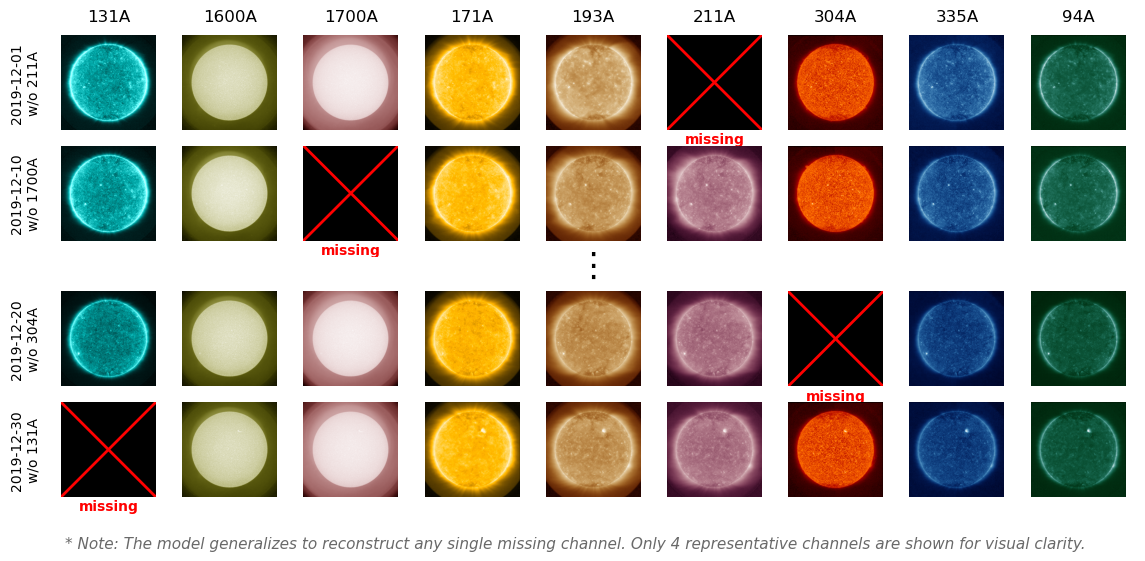

In [11]:
timestamps = [
    "2019-12-01",
    "2019-12-10",
    "2019-12-20",
    "2019-12-30"
    ]

# Explicitly map: (sample_idx, missing_channel_idx)
target_corruptions = [(0, 5), (1, 2), None, (2, 6), (3, 0)]
outputs_to_plot = []

x_input = x_set.clone()

# 1. Zero out the specific channel for the specific sample
for item in target_corruptions:
    if item is not None:
        b_idx, c_idx = item
        x_input[b_idx, c_idx, :, :, :] = 0 

# 2. Get model output
loss, output, mask = model(x_input)

# (Optional: Assuming you create output_denorm here. E.g., output_denorm = denorm_fn(output))
# For this script, we will pull directly from output_denorm (or output) below.
# Let's assume output_denorm has the shape [4, C, Z, Y, X]
output_denorm = output # Replace this with your actual denormalization step

# 3. Store the specific samples for plotting
for item in target_corruptions:
    if item is None:
        outputs_to_plot.append(None)
    else:
        b_idx, c_idx = item
        # Zero out the missing channel in the output array for visualization
        output_denorm[b_idx, c_idx, :, :, :] = 0
        # Append just this specific sample (shape becomes [C, Z, Y, X])
        outputs_to_plot.append(output_denorm[b_idx])

# 4. Plotting
norm = TwoSlopeNorm(vmin=-4000, vcenter=0, vmax=4000)
fig, axes = plt.subplots(
    nrows=5, 
    ncols=9, 
    figsize=(14, 6), 
    gridspec_kw={
        'height_ratios': [1, 1, 0.2, 1, 1],
        'wspace': 0.05,  
        'hspace': 0.20   
    }
)

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

for row_idx, item in enumerate(target_corruptions):
    
    # Handle the ellipsis row
    if item is None:
        axes[row_idx, 4].text(
            0.5, 0.5, 
            "⋮", 
            fontsize=24, 
            ha="center", 
            va="center"
        )
        continue

    # Unpack the sample index and corrupted channel index
    b_idx, corr_ch = item
    current_sample_output = outputs_to_plot[row_idx] 

    for i_ch, ch in enumerate(channels[:9]):
        
        # Add column titles only to the top row
        if row_idx == 0:
            axes[0, i_ch].set_title(f"{ch}", fontsize=12, pad=10)

        # Add row labels to the first column
        if i_ch == 0:
            # Grab the correct timestamp using the batch index
            current_time = timestamps[b_idx]
            
            # Format the label with the timestamp on top
            label_text = f"{current_time}\nw/o {channels[corr_ch]}"
            
            axes[row_idx, 0].set_ylabel(label_text, fontsize=10, labelpad=15)
            axes[row_idx, 0].spines['left'].set_visible(False)
        # ----------------------------

        # If this is the missing channel, draw the red "X"
        if i_ch == corr_ch:
            axes[row_idx, i_ch].set_facecolor("black")
            axes[row_idx, i_ch].set_aspect("equal")
            axes[row_idx, i_ch].set_xlim(0, 1)
            axes[row_idx, i_ch].set_ylim(0, 1)
            axes[row_idx, i_ch].plot([0, 1], [0, 1], color="red", linewidth=2)
            axes[row_idx, i_ch].plot([0, 1], [1, 0], color="red", linewidth=2)
            axes[row_idx, i_ch].text(
                0.5, -0.1, "missing",
                color="red", ha="center", va="center",
                fontsize=10, fontweight="bold"
            )
        else:
            # Plot the actual model output for the remaining channels
            # Note: current_sample_output[i_ch, 0, :, :] selects the correct channel and Z-slice
            
            # If your tensors are on GPU, you may need to add .detach().cpu().numpy()
            img_data = current_sample_output[i_ch, 0, :, :].detach().cpu().numpy()
            
            axes[row_idx, i_ch].imshow(
                img_data, 
                cmap=cms_dict[ch], 
                norm=norm if i_ch >= 9 else None
            )

# Add the built-in caption
fig.text(
    0.5, 0.02, 
    "* Note: The model generalizes to reconstruct any single missing channel. Only 4 representative channels are shown for visual clarity.",
    ha="center", va="bottom", fontsize=11, style="italic", color="dimgray"
)

plt.tight_layout()
plt.savefig("DS_missing_data_img_result_with_4missing_aia.pdf", dpi=300, bbox_inches="tight")
plt.show()